<a href="https://colab.research.google.com/github/foezhasa/Sale-Analysis/blob/main/Sale_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Sales in King County, USA**

nstructions
In this assignment, you are a Data Analyst working at a Real Estate Investment Trust. The Trust would like to start investing in Residential real estate. You are tasked with determining the market price of a house given a set of features. You will analyze and predict housing prices using attributes or features such as square footage, number of bedrooms, number of floors, and so on. This is a template notebook; your job is to complete the ten questions. Some hints to the questions are given.

As you are completing this notebook, take and save the screenshots of the final outputs of your solutions (e.g., final charts, tables, calculation results etc.). They will need to be shared in the following Peer Review section of the Final Project module.

**About the Dataset**

This dataset contains house sale prices for King County, which includes Seattle. It includes homes sold between May 2014 and May 2015. It was taken from here. It was also slightly modified for the purposes of this course.

| Variable      | Description                                                                                                 |
| ------------- | ----------------------------------------------------------------------------------------------------------- |
| id            | A notation for a house                                                                                      |
| date          | Date house was sold                                                                                         |
| price         | Price is prediction target                                                                                  |
| bedrooms      | Number of bedrooms                                                                                          |
| bathrooms     | Number of bathrooms                                                                                         |
| sqft_living   | Square footage of the home                                                                                  |
| sqft_lot      | Square footage of the lot                                                                                   |
| floors        | Total floors (levels) in house                                                                              |
| waterfront    | House which has a view to a waterfront                                                                      |
| view          | Has been viewed                                                                                             |
| condition     | How good the condition is overall                                                                           |
| grade         | overall grade given to the housing unit, based on King County grading system                                |
| sqft_above    | Square footage of house apart from basement                                                                 |
| sqft_basement | Square footage of the basement                                                                              |
| yr_built      | Built Year                                                                                                  |
| yr_renovated  | Year when house was renovated                                                                               |
| zipcode       | Zip code                                                                                                    |
| lat           | Latitude coordinate                                                                                         |
| long          | Longitude coordinate                                                                                        |
| sqft_living15 | Living room area in 2015(implies-- some renovations) This might or might not have affected the lotsize area |
| sqft_lot15    | LotSize area in 2015(implies-- some renovations)                                                            |


# **Importing Libraries & Setup**

In this section, necessary libraries for data analysis, visualization, and machine learning are imported. Warnings are suppressed to ensure a cleaner output.

In [7]:

# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [8]:
import warnings
warnings.filterwarnings('ignore')

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

%matplotlib inline

# **Load Dataset & Preview**

The dataset is loaded from an external source and inspected to understand its structure and variables.

The dataset contains housing features such as size, number of rooms, and location, which will be used to predict house prices.

In [10]:
filepath = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv"

df = pd.read_csv(filepath)

df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# **Data Types (df.dtypes)**

The data types of each variable are examined to identify numerical and categorical features.

What it does:

Shows column types

Interpretation:

Most variables are numerical, making them suitable for regression analysis. The date column is an object and may require transformation if used.

In [11]:
df.dtypes

,0
Unnamed: 0,int64
id,int64
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64


In [12]:
print(df.dtypes)

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


# **Statistical Summary (describe())**

A statistical summary is generated to understand the distribution, central tendency, and spread of the data.


The average house price is around 540,000, with a wide range, indicating significant variation in the dataset.

In [13]:
df.describe()

,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21613.00000,2.161300e+04,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,10806.00000,4.580302e+09,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,6239.28002,2.876566e+09,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,0.00000,1.000102e+06,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,5403.00000,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,10806.00000,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,16209.00000,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,21612.00000,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


Question 2

# **Drop Irrelevant Columns**

Irrelevant features such as ID are removed, as they do not contribute to price prediction.

Removing non-informative variables improves model performance and reduces complexity.

In [14]:
df.drop(["id", "Unnamed: 0"], axis=1, inplace=True)

# **Handling Missing Values**

Missing values in key variables such as bedrooms and bathrooms are handled using mean imputation.

This ensures the dataset is complete and prevents errors during model training.

In [16]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 13
number of NaN values for the column bathrooms : 10


In [17]:
mean_bedrooms = df['bedrooms'].mean()
df['bedrooms'].fillna(mean_bedrooms, inplace=True)

In [18]:
print("number of NaN values for the column bedrooms :", df['bedrooms'].isnull().sum())
print("number of NaN values for the column bathrooms :", df['bathrooms'].isnull().sum())

number of NaN values for the column bedrooms : 0
number of NaN values for the column bathrooms : 10


# **Floors Distribution**

The distribution of the number of floors is analyzed to understand housing structure patterns.

Most houses have 1 or 2 floors, indicating typical residential structures.

In [19]:
floor_counts = df["floors"].value_counts().to_frame()
floor_counts

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


# **Waterfront vs Price (Boxplot)**

A boxplot is used to compare house prices based on whether the property has a waterfront view.


Houses with a waterfront view have significantly higher median prices, indicating that location and view strongly impact property value.

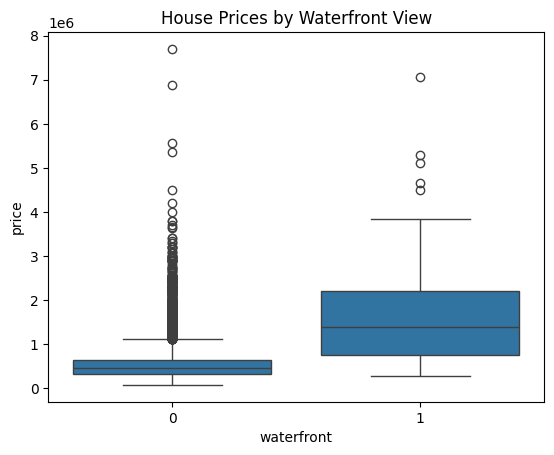

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="waterfront", y="price", data=df)

plt.title("House Prices by Waterfront View")
plt.show()

# **Sqft Above vs Price (Regplot)**

A regression plot is used to examine the relationship between living space above ground and house price.

There is a clear positive relationship, suggesting that larger living areas lead to higher prices.

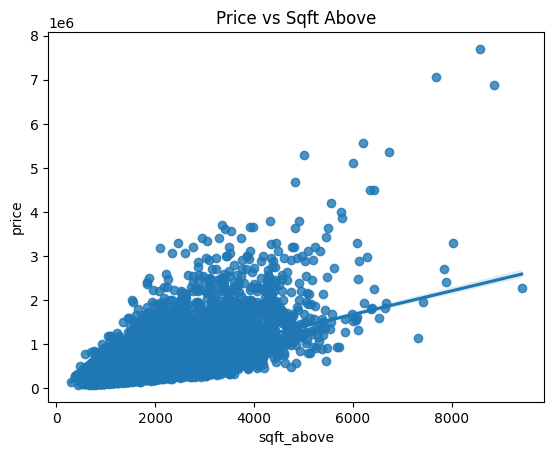

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="sqft_above", y="price", data=df)

plt.title("Price vs Sqft Above")
plt.show()

In [22]:
df_numeric = df.select_dtypes(include=[np.number])
df_numeric.corr()['price'].sort_values(ascending=False)

,price
price,1.000000
sqft_living,0.702035
grade,0.667434
sqft_above,0.605567
sqft_living15,0.585379
bathrooms,0.525885
view,0.397293
sqft_basement,0.323816
bedrooms,0.308797
lat,0.307003


# **Linear Regression (long → price)**

A simple linear regression model is built using longitude as a predictor.

The very low R² (~0.0004) indicates that longitude alone has almost no predictive power.

In [23]:
from sklearn.linear_model import LinearRegression

X = df[['long']]
Y = df['price']

lm = LinearRegression()
lm.fit(X, Y)

lm.score(X, Y)

0.00046769430149007363

# **Linear Regression (sqft_living → price)**

A linear regression model is built using living area as the predictor.

The R² (~0.49) shows that nearly half of the variance in price can be explained by living space alone.

In [24]:
from sklearn.linear_model import LinearRegression

X = df[['sqft_living']]
Y = df['price']

lm = LinearRegression()
lm.fit(X, Y)

lm.score(X, Y)

0.4928532179037931

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

Input = [
    ('scale', StandardScaler()),
    ('polynomial', PolynomialFeatures(include_bias=False)),
    ('model', LinearRegression())
]

In [28]:
from sklearn.model_selection import train_test_split

features = ["floors", "waterfront","lat","bedrooms","sqft_basement",
            "view","bathrooms","sqft_living15","sqft_above","grade","sqft_living"]

X = df[features]
Y = df['price']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

print("number of test samples:", x_test.shape[0])
print("number of training samples:", x_train.shape[0])

number of test samples: 3242
number of training samples: 18371


# **Heatmap**

A heatmap visualizes correlations between all numerical variables.

Strong relationships are observed between price and size-related features, confirming earlier findings.

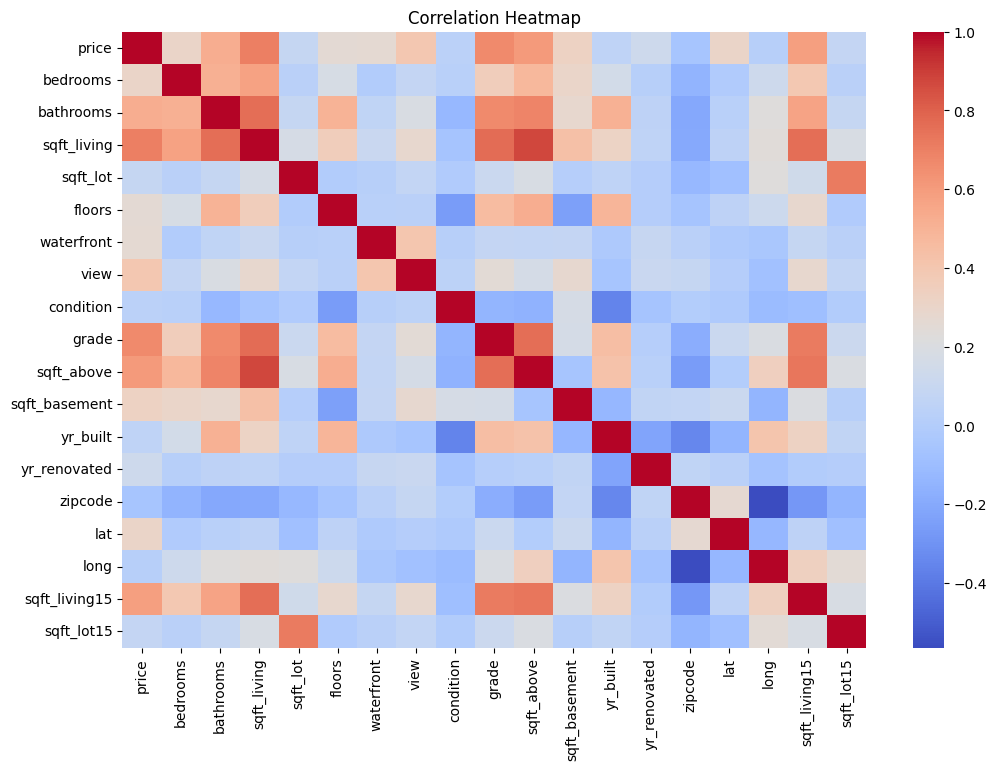

In [34]:
plt.figure(figsize=(12,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=False, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# **Top Features Bar Plot**

The most influential features affecting house price are visualized.

Living area, grade, and above-ground space are the most significant predictors.

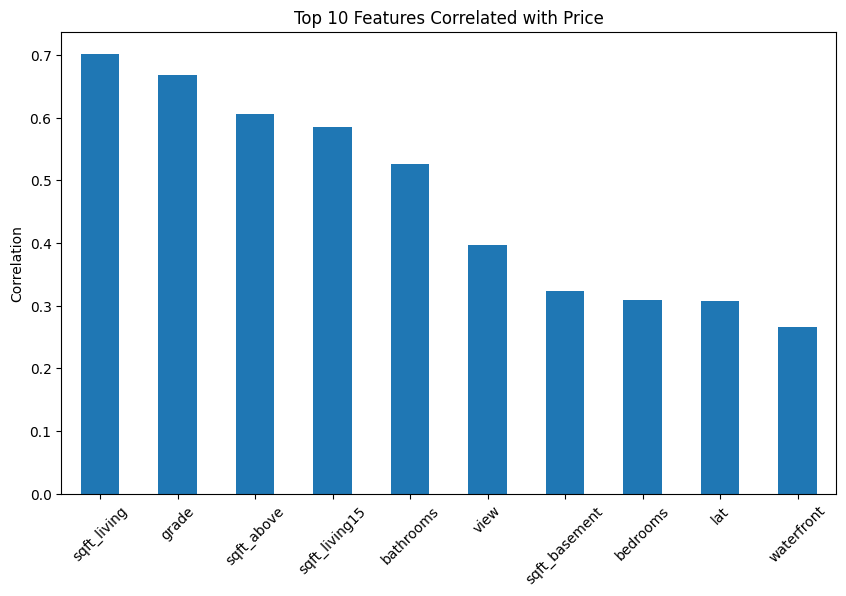

In [35]:
corr_price = df_numeric.corr()['price'].sort_values(ascending=False)

corr_price = corr_price.drop('price')  # remove self-correlation

plt.figure(figsize=(10,6))
corr_price.head(10).plot(kind='bar')

plt.title("Top 10 Features Correlated with Price")
plt.ylabel("Correlation")
plt.xticks(rotation=45)

plt.show()

# **Price Distribution**


The distribution of house prices is examined.

The histogram shows a strongly right-skewed (positively skewed) distribution. This has several important statistical implications:

1. Skewness and Central Tendency
The bulk of observations is concentrated at lower price levels, with a long tail extending to very high values.

This implies:

mean>median>mode

A small number of very expensive houses pull the mean upward, making it non-representative of the typical case.

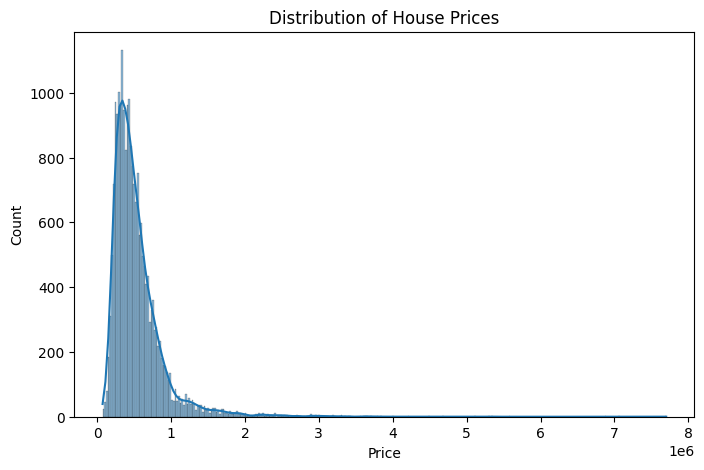

In [64]:
plt.figure(figsize=(8,5))

sns.histplot(df['price'], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")

plt.show()

# **Scatter Plot (sqft_living vs price)**

A scatter plot visualizes the relationship between house size and price.

A strong upward trend confirms that larger houses tend to be more expensive.

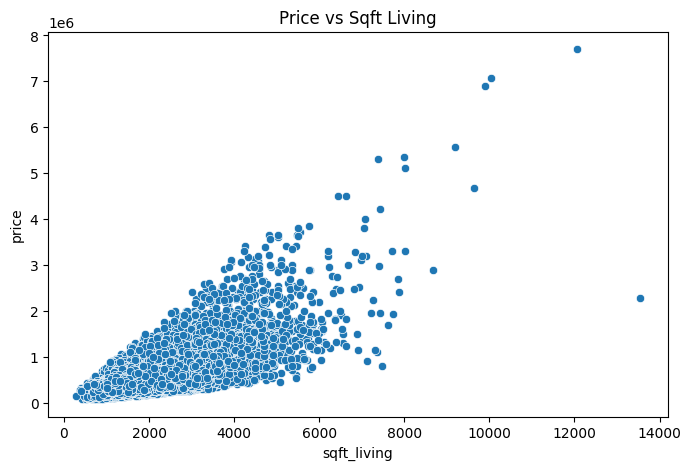

In [65]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="sqft_living", y="price", data=df)

plt.title("Price vs Sqft Living")

plt.show()

# **Regression Plot (Improved)**

A regression line is added to better understand the relationship between size and price.

The linear trend confirms a strong positive correlation between living space and price.

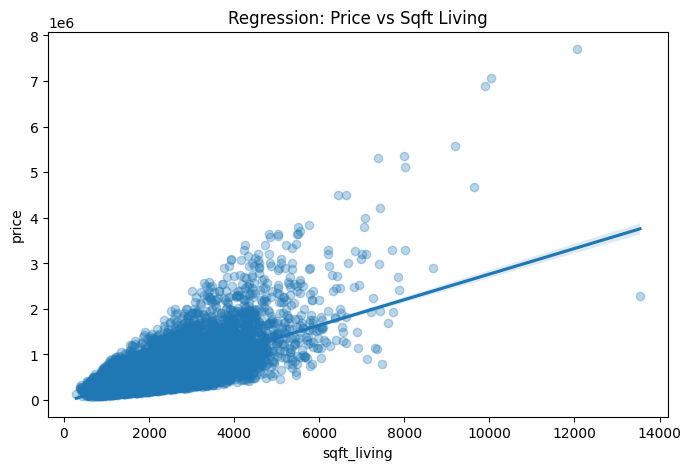

In [38]:
plt.figure(figsize=(8,5))

sns.regplot(x="sqft_living", y="price", data=df, scatter_kws={'alpha':0.3})

plt.title("Regression: Price vs Sqft Living")

plt.show()

# **Grade vs Price (Boxplot)**

The relationship between house grade and price is analyzed.

Higher-grade houses have significantly higher prices, indicating quality strongly influences value.

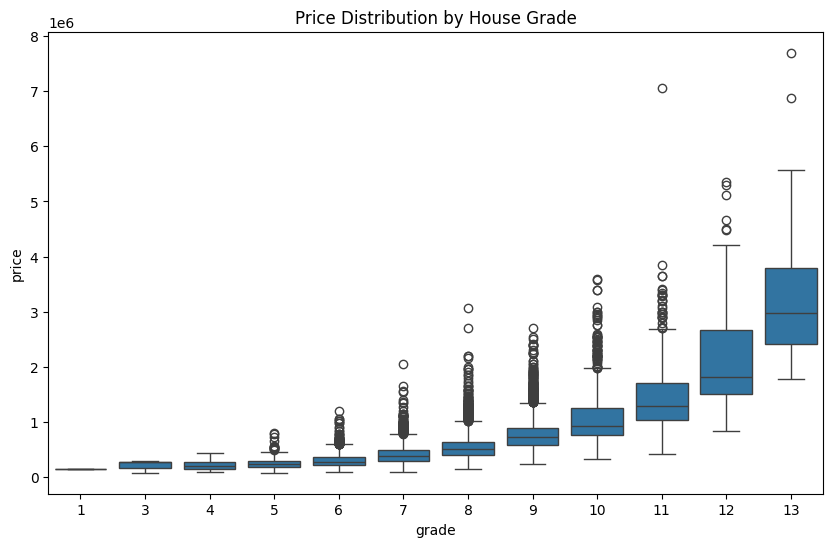

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(x="grade", y="price", data=df)

plt.title("Price Distribution by House Grade")

plt.show()

# **Log Transformation**

A logarithmic transformation is applied to reduce skewness in the price distribution.

The transformed distribution becomes more normal, improving model performance.

In [41]:
import numpy as np

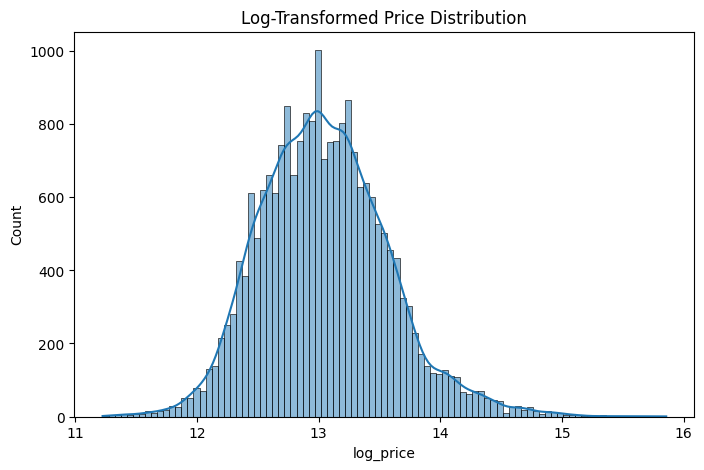

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df['log_price'] = np.log(df['price'])

plt.figure(figsize=(8,5))
sns.histplot(df['log_price'], kde=True)

plt.title("Log-Transformed Price Distribution")
plt.show()

# **Before vs After**

The original and transformed price distributions are compared.

Log transformation reduces extreme values and creates a more symmetric distribution.

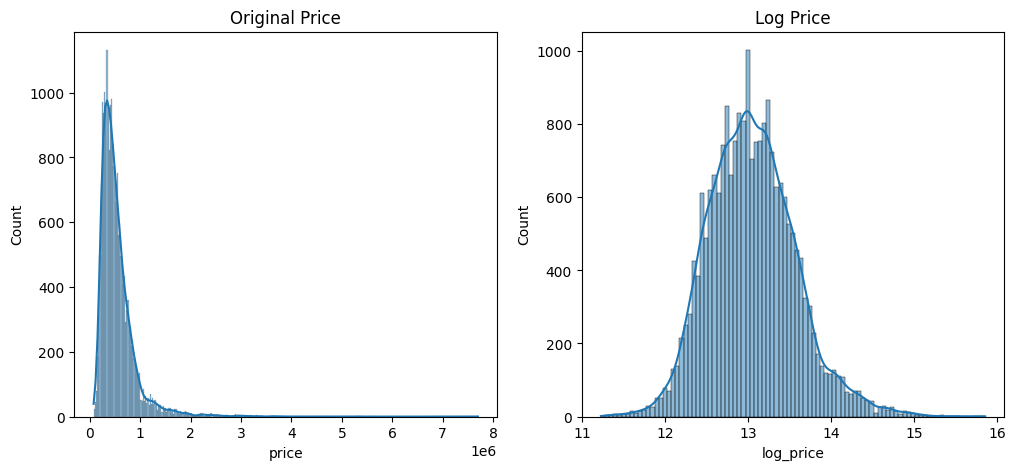

In [43]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True)
plt.title("Original Price")

plt.subplot(1,2,2)
sns.histplot(df['log_price'], kde=True)
plt.title("Log Price")

plt.show()

# **Pipeline Model**

A machine learning pipeline is built to automate preprocessing and modeling steps.

The pipeline improves robustness by handling missing values, scaling data, and applying regularization.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer

In [55]:
features = ["floors", "waterfront","lat","bedrooms","sqft_basement",
            "view","bathrooms","sqft_living15","sqft_above","grade","sqft_living"]

X = df[features]
Y = df['price']

In [56]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=1)

In [57]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),   # handles NaN
    ('scaler', StandardScaler()),                  # normalize
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # interactions
    ('model', Ridge(alpha=0.1))                    # model
])

In [58]:
pipe.fit(x_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(include_bias=False)),
                ('model', Ridge(alpha=0.1))])

# **Model Evaluation**

The model is evaluated using R² on both training and test data.

A smaller gap between train and test R² indicates good generalization performance.

In [59]:
print("Train R²:", pipe.score(x_train, y_train))
print("Test R²:", pipe.score(x_test, y_test))

Train R²: 0.7539142476337807
Test R²: 0.7117271818841076


In [60]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X, Y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV score:", scores.mean())

Cross-validation scores: [0.75793033 0.7392782  0.71418899 0.70420159 0.73736545]
Average CV score: 0.7305929120578833


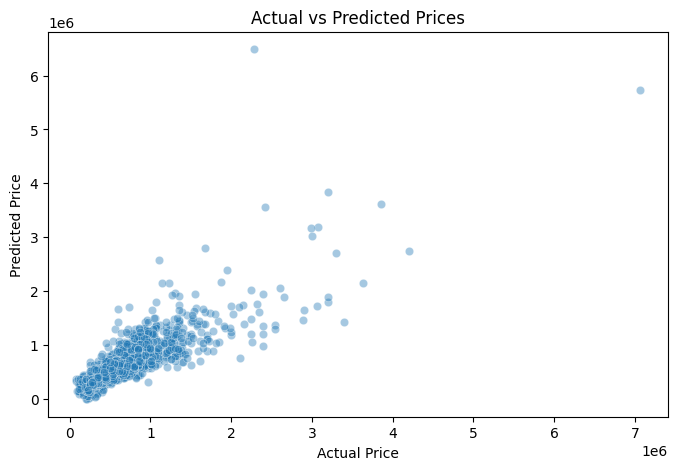

In [61]:
y_pred = pipe.predict(x_test)

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

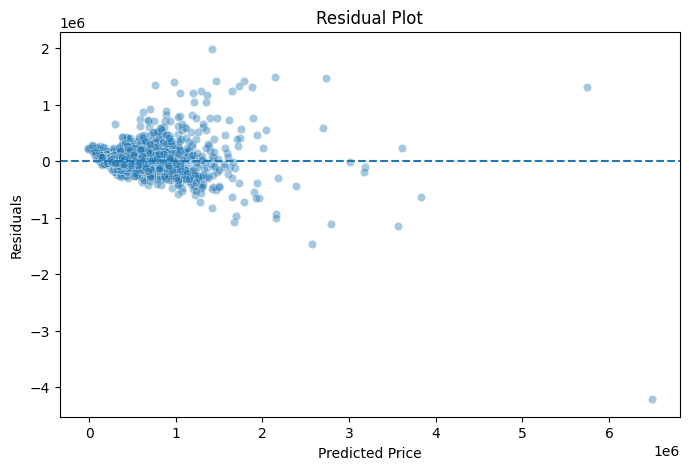

In [62]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals, alpha=0.4)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

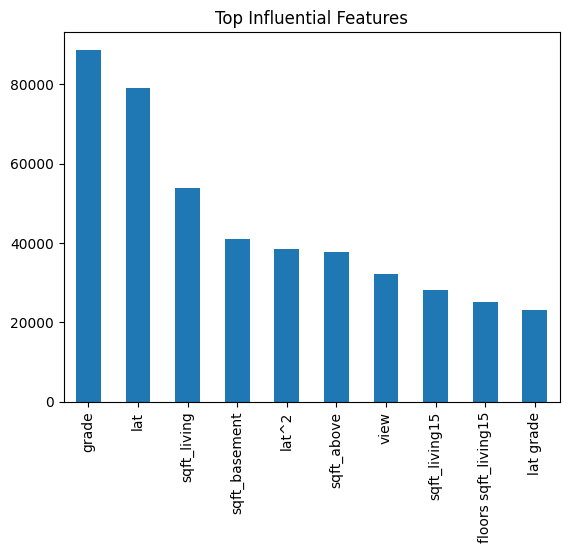

In [63]:
model = pipe.named_steps['model']
feature_names = pipe.named_steps['poly'].get_feature_names_out(features)

coeffs = pd.Series(model.coef_, index=feature_names)

top_features = coeffs.abs().sort_values(ascending=False).head(10)

top_features.plot(kind='bar')

plt.title("Top Influential Features")
plt.show()

# **Conclusion**


The analysis shows that house prices are primarily driven by property size and quality. Models using multiple features significantly outperform single-variable models. The use of pipelines and regularization ensures robust and reliable predictions.